# Set up

In [1]:
%reload_ext autoreload
%autoreload 2

%cd "/Users/dunglai/Desktop/Việt Dũng/Personal Projects/World Foresight Framework/Data Preparation"

/Users/dunglai/Desktop/Việt Dũng/Personal Projects/World Foresight Framework/Data Preparation


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import Analysis_Functions as af

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

PROJECT_ROOT = Path("/Users/dunglai/Desktop/Việt Dũng/Personal Projects/World Foresight Framework")

In [3]:
full_data_to_2040 = pd.read_excel(PROJECT_ROOT / "Final Data.xlsx", sheet_name="Final Full Data")

full_data_to_2040["value"] = full_data_to_2040["value"].astype(float)
full_data_to_2040["year"] = full_data_to_2040["year"].astype(int)

proxy_info = pd.read_excel(PROJECT_ROOT / "Final Data.xlsx", sheet_name="Proxy Information")
statistical_data = pd.read_excel(PROJECT_ROOT / "Final Data.xlsx", sheet_name="Statistical Data")

PROXY_NAME = proxy_info.set_index("id")["proxy_name"].to_dict()

full_data_to_2040.head(5)

,Unnamed: 0,proxy_id,id,market,year,value,labels,scenario,lower_ci,upper_ci
0,0,D1_ARE,D1,ARE,2000,5875.833901,USD (millions),historical,NaN,NaN
1,1,D1_ARE,D1,ARE,2001,5797.957794,USD (millions),historical,NaN,NaN
2,2,D1_ARE,D1,ARE,2002,5354.118448,USD (millions),historical,NaN,NaN
3,3,D1_ARE,D1,ARE,2003,5834.717495,USD (millions),historical,NaN,NaN
4,4,D1_ARE,D1,ARE,2004,6816.882233,USD (millions),historical,NaN,NaN


In [4]:
# Anchor-year slices. 2025 is the splice year, so it needs both scenarios.
def anchor_slice(year, scenario="main_scenario"):
    scenarios = ["historical", scenario] if year <= 2025 else [scenario]
    return full_data_to_2040[
        (full_data_to_2040["year"] == year) & (full_data_to_2040["scenario"].isin(scenarios))
    ]

main_2025_data = anchor_slice(2025)
main_2030_data = anchor_slice(2030)
main_2040_data = anchor_slice(2040)

ANCHORS = {"2025": main_2025_data, "2030": main_2030_data, "2040": main_2040_data}

print({k: len(v) for k, v in ANCHORS.items()})

{'2025': 5316, '2030': 5316, '2040': 5316}


# Data reality check

Run before reading any 2040 number. The forecaster is a damped blended trend with an
effective drift horizon of ~2.6-5.7 years (`PIPELINE_METHODOLOGY.md` s.6), so a 2040
value is roughly "last observation + a few years of trend, then flat".

Consequence for every topic below: **shares, ranks, gaps and compositions are reliable;
absolute levels and growth rates are conservative floors, not forecasts.**

In [5]:
# How much of each series' historical growth survives into the forecast?
damping_check = []
for pid in ["D142", "D62", "D59", "D60", "D22", "D26", "D104", "D83"]:
    for mkt in ["GLO", "USA", "CHN", "IND"]:
        row = af.growth_profile(full_data_to_2040, [pid], market=mkt, history_start=2010)
        if len(row) and pd.notna(row["hist_cagr_pct"].iloc[0]):
            damping_check.append({
                "id": pid, "market": mkt,
                "hist_cagr_pct": row["hist_cagr_pct"].iloc[0],
                "fwd_cagr_pct": row["fwd_cagr_pct"].iloc[0],
            })

damping_check = pd.DataFrame(damping_check)
damping_check["retained"] = (damping_check["fwd_cagr_pct"] / damping_check["hist_cagr_pct"]).round(2)

print(f"median share of historical growth retained: {damping_check['retained'].median():.0%}")
display(damping_check)

/var/folders/7h/7c1b1_6n6338cw_hpfm381000000gn/T/ipykernel_63232/1708614724.py:5: UserWarning: growth_profile: D142 not found for GLO; skipped
  row = af.growth_profile(full_data_to_2040, [pid], market=mkt, history_start=2010)
/var/folders/7h/7c1b1_6n6338cw_hpfm381000000gn/T/ipykernel_63232/1708614724.py:5: UserWarning: growth_profile: D62 not found for GLO; skipped
  row = af.growth_profile(full_data_to_2040, [pid], market=mkt, history_start=2010)
/var/folders/7h/7c1b1_6n6338cw_hpfm381000000gn/T/ipykernel_63232/1708614724.py:5: UserWarning: growth_profile: D59 not found for USA; skipped
  row = af.growth_profile(full_data_to_2040, [pid], market=mkt, history_start=2010)
/var/folders/7h/7c1b1_6n6338cw_hpfm381000000gn/T/ipykernel_63232/1708614724.py:5: UserWarning: growth_profile: D59 not found for CHN; skipped
  row = af.growth_profile(full_data_to_2040, [pid], market=mkt, history_start=2010)
/var/folders/7h/7c1b1_6n6338cw_hpfm381000000gn/T/ipykernel_63232/1708614724.py:5: UserWarning: 

median share of historical growth retained: 16%


/var/folders/7h/7c1b1_6n6338cw_hpfm381000000gn/T/ipykernel_63232/1708614724.py:5: UserWarning: growth_profile: D83 not found for GLO; skipped
  row = af.growth_profile(full_data_to_2040, [pid], market=mkt, history_start=2010)


,id,market,hist_cagr_pct,fwd_cagr_pct,retained
0,D142,USA,4.9,0.8,0.16
1,D142,CHN,7.9,1.3,0.16
2,D142,IND,5.9,1.1,0.19
3,D62,USA,-0.9,-0.3,0.33
4,D62,CHN,2.5,0.8,0.32
5,D62,IND,3.4,0.7,0.21
6,D59,GLO,0.6,0.1,0.17
7,D60,GLO,11.2,1.2,0.11
8,D22,USA,2.3,0.0,0.00
9,D22,CHN,4.2,0.6,0.14


In [6]:
# GLO context series where the damping is most visible
context_growth = af.growth_profile(
    full_data_to_2040,
    ["D58", "D59", "D60", "D61", "D19", "D57"],
    market="GLO",
    history_start=2010,
)
context_growth["proxy_name"] = context_growth["proxy_id"].map(PROXY_NAME)
display(context_growth)

print("Unusable as levels — flat or floored series:")
for pid in ["D18", "D20"]:
    s = full_data_to_2040[(full_data_to_2040["id"] == pid) & (full_data_to_2040["market"] == "GLO")]
    print(f"  {pid} {PROXY_NAME.get(pid, '')}: 2025={s.loc[s['year'] == 2025, 'value'].values}, "
          f"2040={s.loc[s['year'] == 2040, 'value'].values}")

,proxy_id,v2025,v2040,hist_cagr_pct,fwd_cagr_pct,doubling_years,multiple,proxy_name
0,D58,1.130000e+00,1.232700e+00,3.1,0.6,119.5,1.1,Global Mean Surface Temperature Anomaly (°C)
1,D59,4.256400e+02,4.330382e+02,0.6,0.1,603.4,1.0,Atmospheric CO₂ Concentration (ppm)
2,D60,6.167010e+01,7.419510e+01,11.2,1.2,56.2,1.2,Global Mean Sea-Level Change (mm)
3,D61,2.284500e+01,2.615800e+01,5.4,0.9,76.8,1.1,Global Ocean Heat Content (10²² J)
4,D19,1.809000e+06,2.046244e+06,54.8,0.8,84.4,1.1,TOP500 #1 Performance (TFlop/s)
5,D57,1.410000e+02,1.482130e+02,NaN,0.3,208.4,1.1,Daily Time Spent on Social Media (minutes)


Unusable as levels — flat or floored series:
  D18 Frontier AI Training Compute (FLOP): 2025=[6.339 6.339 6.339], 2040=[6.339 6.339 6.339]
  D20 Human Genome Sequencing Cost (USD): 2025=[0.       0.104925 0.      ], 2040=[0.       0.104925 0.      ]


# Topic 1: Power

## Q1: What shape does the world order take?

Proxies: D1 military budget, D2 trade, D3 soft power, D4 GDP, D5 national capability.
D3 is excluded from the additive composite (0-100 index, not summable) and read separately.

In [7]:
Q1_SCORE_IDS = ["D1", "D2", "D3", "D4", "D5"]
Q1_SHARE_IDS = ["D1", "D2", "D4", "D5"]

q1_direction_config = [{"id": pid, "direction": "positive"} for pid in Q1_SCORE_IDS]

for label, data in ANCHORS.items():
    ranking = af.rank_market_relevance(data[data["id"].isin(Q1_SCORE_IDS)], q1_direction_config)
    print(label, "->", ", ".join(f"{r.market}" for r in ranking.head(8).itertuples()))

2025 -> CHN, USA, DEU, GBR, IND, JPN, FRA, RUS
2030 -> CHN, USA, DEU, IND, GBR, JPN, FRA, RUS
2040 -> CHN, USA, DEU, IND, GBR, JPN, FRA, RUS


In [8]:
# World power share at each anchor year
for label, data in ANCHORS.items():
    ranking, hhi, share_detail = af.analyze_share_of_world(data[data["id"].isin(Q1_SHARE_IDS)], Q1_SHARE_IDS)
    print(label, "->", ", ".join(f"{r.market} {r.average_share:.1f}%" for r in ranking.head(6).itertuples()))

display(hhi)

2025 -> USA 25.2%, CHN 19.9%, IND 6.0%, DEU 4.9%, RUS 4.1%, GBR 3.6%
2030 -> USA 24.9%, CHN 20.4%, IND 6.2%, DEU 4.9%, RUS 4.1%, GBR 3.5%
2040 -> USA 24.7%, CHN 20.7%, IND 6.3%, DEU 4.8%, RUS 4.1%, GBR 3.4%


,id,hhi,effective_markets
0,D1,1731.633913,5.774893
1,D2,818.019512,12.224647
2,D4,1532.566332,6.525003
3,D5,1379.487352,7.249070


,2000,2005,2010,2015,2020,2025,2030,2035,2040
market,,,,,,,,,
USA,31.62,31.10,28.15,26.35,26.35,25.18,24.89,24.75,24.68
CHN,8.09,9.88,14.08,18.62,20.43,19.91,20.44,20.65,20.73
IND,3.41,3.94,4.80,5.08,5.75,6.04,6.17,6.23,6.25
DEU,6.22,6.19,5.44,4.81,4.97,4.95,4.87,4.85,4.84
RUS,2.60,3.04,3.65,3.36,3.01,4.11,4.10,4.11,4.11
GBR,5.67,5.67,4.16,4.07,3.48,3.56,3.45,3.41,3.39
JPN,9.90,7.32,6.33,4.86,4.61,3.51,3.35,3.29,3.27
FRA,4.67,4.84,4.06,3.49,3.32,3.07,3.01,2.99,2.99


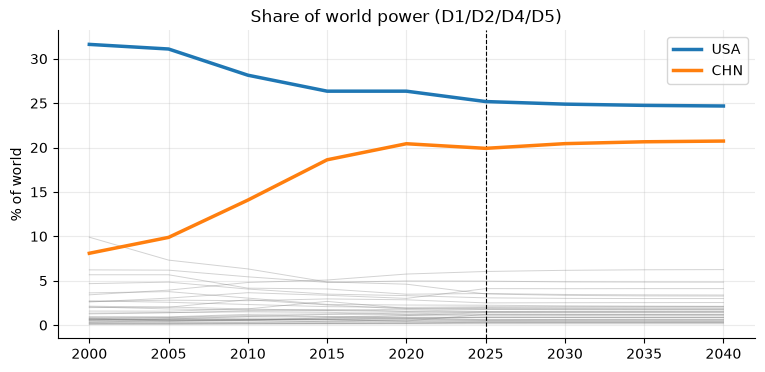

In [9]:
# Full trajectory 2000 -> 2040: when did the redistribution actually happen?
YEARS = [2000, 2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040]

share_path = af.share_trajectory(full_data_to_2040, Q1_SHARE_IDS, YEARS)
display(share_path.head(8))

fig, ax = plt.subplots()
for mkt in share_path.index:
    if mkt in ("USA", "CHN"):
        ax.plot(YEARS, share_path.loc[mkt], lw=2.5, label=mkt, zorder=3)
    else:
        ax.plot(YEARS, share_path.loc[mkt], lw=0.7, color="grey", alpha=0.35)
ax.axvline(2025, ls="--", c="k", lw=0.8)
ax.set_title("Share of world power (D1/D2/D4/D5)")
ax.set_ylabel("% of world")
ax.legend()
plt.show()

,year,hhi,effective_markets,top2_share,rank3_10_share,rank11plus_share
0,2000,1326.3,7.54,41.5,37.1,21.8
1,2005,1289.3,7.76,41.0,37.6,21.6
2,2010,1182.8,8.45,42.2,34.3,23.6
3,2015,1203.6,8.31,45.0,31.3,23.9
4,2020,1266.2,7.90,46.8,30.2,23.1
5,2025,1188.8,8.41,45.1,30.0,25.1
6,2030,1194.0,8.37,45.3,29.6,25.2
7,2035,1195.5,8.36,45.4,29.6,25.2
8,2040,1195.3,8.37,45.4,29.5,25.2


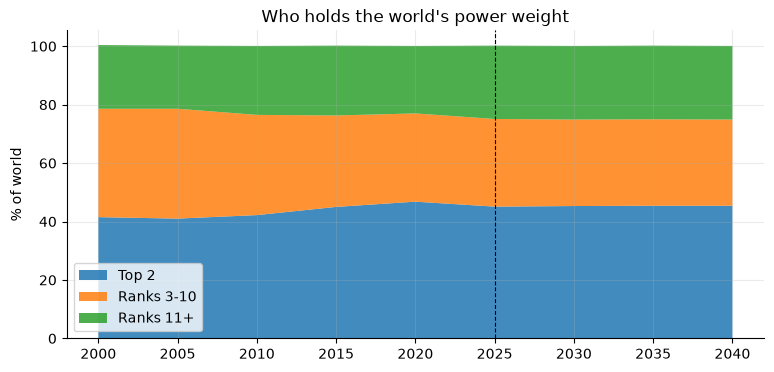

In [10]:
# Is power concentrating or diffusing?
concentration = af.concentration_trend(full_data_to_2040, Q1_SHARE_IDS, YEARS)
display(concentration)

fig, ax = plt.subplots()
ax.stackplot(concentration["year"],
             concentration["top2_share"], concentration["rank3_10_share"], concentration["rank11plus_share"],
             labels=["Top 2", "Ranks 3-10", "Ranks 11+"], alpha=0.85)
ax.axvline(2025, ls="--", c="k", lw=0.8)
ax.set_title("Who holds the world's power weight")
ax.set_ylabel("% of world")
ax.legend(loc="lower left")
plt.show()

In [11]:
# Bloc-level shares
blocs = {
    "West (US + NATO/EU + Pacific)": ["USA", "CAN", "GBR", "FRA", "DEU", "ITA", "NLD", "POL", "JPN", "KOR", "AUS"],
    "China + Russia":                ["CHN", "RUS"],
    "India (swing pole)":            ["IND"],
}
assigned = {m for members in blocs.values() for m in members}
blocs["Rest / Global South"] = [m for m in share_path.index if m not in assigned]

bloc_shares = pd.DataFrame([
    {"bloc": name,
     "share_2025": share_path.loc[members, 2025].sum(),
     "share_2040": share_path.loc[members, 2040].sum()}
    for name, members in blocs.items()
]).round(1)
bloc_shares["change"] = (bloc_shares["share_2040"] - bloc_shares["share_2025"]).round(1)
display(bloc_shares)

,bloc,share_2025,share_2040,change
0,West (US + NATO/EU + Pacific),51.8,50.5,-1.3
1,China + Russia,24.0,24.8,0.8
2,India (swing pole),6.0,6.2,0.2
3,Rest / Global South,18.3,18.5,0.2


In [12]:
# Does the hierarchy depend on the scenario we picked?
display(af.ranking_stability(full_data_to_2040, Q1_SHARE_IDS, year=2040, top_n=8))

us_cn = af.scenario_spread(full_data_to_2040, Q1_SHARE_IDS, year=2040, markets=["USA", "CHN"])
display(us_cn)

,market,main,optimistic,pessimistic,best_rank,worst_rank,rank_swing
0,USA,1.0,1.0,1.0,1,1,0
1,CHN,2.0,2.0,2.0,2,2,0
2,IND,3.0,3.0,3.0,3,3,0
3,DEU,4.0,4.0,4.0,4,4,0
4,RUS,5.0,5.0,5.0,5,5,0
5,GBR,6.0,6.0,6.0,6,6,0
6,JPN,7.0,7.0,7.0,7,7,0
7,FRA,8.0,8.0,8.0,8,8,0


,id,market,main,optimistic,pessimistic,spread,spread_pct,scenario_robust
0,D1,CHN,4.040162e+05,4.108654e+05,3.971670e+05,13698.411949,3.390560,True
1,D1,USA,1.035483e+06,1.051702e+06,1.019263e+06,32438.229950,3.132668,True
2,D2,CHN,8.204400e+03,8.423471e+03,7.985329e+03,438.142274,5.340333,True
3,D2,USA,8.328725e+03,8.428678e+03,8.228772e+03,199.905825,2.400197,True
4,D4,CHN,2.299263e+01,2.341892e+01,2.256633e+01,0.852591,3.708106,True
5,D4,USA,3.300230e+01,3.337273e+01,3.263187e+01,0.740857,2.244865,True
6,D5,CHN,2.509400e-01,2.526250e-01,2.492560e-01,0.003369,1.342552,True
7,D5,USA,1.169410e-01,1.176030e-01,1.162780e-01,0.001325,1.133050,True


In [13]:
# Soft power (D3) — the one power proxy left out of the composite
soft = af.anchor_table(full_data_to_2040, "D3", years=[2025, 2030, 2040]).set_index("market")
display(soft.sort_values(2040, ascending=False).head(8))
print("smallest gains:")
display(soft.sort_values("change").head(5))
d3_hist = full_data_to_2040.query("id == 'D3' and scenario == 'historical'")["year"]
print("D3 history:", sorted(d3_hist.unique()))

year,id,2025,2030,2040,change,pct_change
market,,,,,,
GBR,D3,72.4,78.542534,81.920850,9.520850,13.150345
CHN,D3,72.8,78.626024,80.859225,8.059225,11.070364
JPN,D3,71.5,77.492619,80.831716,9.331716,13.051351
USA,D3,74.9,79.260396,80.183892,5.283892,7.054595
DEU,D3,70.1,75.559389,78.681999,8.581999,12.242509
FRA,D3,68.5,74.769584,78.323684,9.823684,14.341145
CAN,D3,65.2,71.414711,75.025093,9.825093,15.069161
ITA,D3,62.4,69.882543,74.200216,11.800216,18.910603


smallest gains:


year,id,2025,2030,2040,change,pct_change
market,,,,,,
ETH,D3,32.1,35.493001,36.299317,4.199317,13.081984
BGD,D3,33.4,37.060273,37.928981,4.528981,13.559823
USA,D3,74.9,79.260396,80.183892,5.283892,7.054595
PAK,D3,35.0,39.794709,41.949798,6.949798,19.856566
RUS,D3,58.1,63.212891,65.354797,7.254797,12.486742


D3 history: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Q2: Who aligns with whom, and who refuses to choose?

Proxies: D6 alignment ideal point, D7_1-4 arms suppliers, D8_1-4 UN votes, D9_1-5 trade shares, D14 votes with majority.

Two methods, deliberately: `cluster_to_anchor` measures closeness *relative to the average
country* (z-scored), `alignment_tilt` measures it in *absolute* terms. They disagree, and
the disagreement is the finding.

In [14]:
# Method 1 — nearest anchor, relative to the average country
for label, data in ANCHORS.items():
    clusters = af.cluster_to_anchor(data)
    print(label, dict(clusters["cluster"].value_counts()))

cluster_2040 = af.cluster_to_anchor(main_2040_data)
for name, group in cluster_2040.groupby("cluster"):
    print(f"  {name}: {', '.join(group['market'])}")

2025 {'USA': np.int64(14), 'IND': np.int64(7), 'CHN': np.int64(6), 'RUS': np.int64(3)}
2030 {'USA': np.int64(14), 'IND': np.int64(7), 'CHN': np.int64(6), 'RUS': np.int64(3)}
2040 {'USA': np.int64(14), 'IND': np.int64(7), 'CHN': np.int64(6), 'RUS': np.int64(3)}
  CHN: COD, IRN, IDN, BRA, PAK, VNM
  IND: ETH, KEN, NGA, BGD, ZAF, ARE, SAU
  RUS: KAZ, TUR, EGY
  USA: CAN, MEX, ISR, GBR, KOR, JPN, ARG, DEU, ITA, AUS, FRA, NLD, UKR, POL


In [15]:
# Method 2 — absolute tilt and hedging balance
for label, data in ANCHORS.items():
    tilt = af.alignment_tilt(data)
    print(f"{label}: mean tilt {tilt['tilt'].mean():+.3f} | mean balance {tilt['balance'].mean():.3f} "
          f"| issue-split {int(tilt['issue_split'].sum())}/{len(tilt)} | {dict(tilt['posture'].value_counts())}")

tilt_2040 = af.alignment_tilt(main_2040_data)
display(tilt_2040)

2025: mean tilt -0.205 | mean balance 0.640 | issue-split 8/32 | {'Hedging': np.int64(15), 'Aligned-East': np.int64(14), 'Autonomous': np.int64(2), 'Aligned-West': np.int64(1)}
2030: mean tilt -0.223 | mean balance 0.621 | issue-split 10/32 | {'Hedging': np.int64(14), 'Aligned-East': np.int64(14), 'Autonomous': np.int64(3), 'Aligned-West': np.int64(1)}
2040: mean tilt -0.234 | mean balance 0.610 | issue-split 10/32 | {'Hedging': np.int64(15), 'Aligned-East': np.int64(14), 'Autonomous': np.int64(2), 'Aligned-West': np.int64(1)}


,market,votes_tilt,votes_balance,trade_tilt,trade_balance,tilt,balance,issue_split,posture
0,CAN,0.270,0.730,0.704,0.296,0.487,0.513,False,Aligned-West
1,ISR,0.534,0.466,-0.130,0.870,0.202,0.668,True,Hedging
2,MEX,-0.199,0.801,0.572,0.428,0.187,0.614,True,Hedging
3,GBR,0.314,0.686,0.054,0.946,0.184,0.816,False,Hedging
4,ITA,0.233,0.767,0.094,0.906,0.163,0.837,False,Hedging
5,NLD,0.237,0.763,0.034,0.966,0.135,0.865,False,Hedging
6,FRA,0.225,0.775,-0.099,0.901,0.063,0.838,True,Hedging
7,DEU,0.248,0.752,-0.171,0.829,0.039,0.790,True,Hedging
8,ARG,0.378,0.622,-0.407,0.593,-0.014,0.607,True,Hedging
9,KOR,0.209,0.791,-0.249,0.751,-0.020,0.771,True,Hedging


In [ ]:
# World centre of gravity: alignment and arms supply
for label, data in ANCHORS.items():
    r = af.world_direction(data, ["D6", "D7_2", "D7_3"]).set_index("id")["weighted_mean"]
    print(f"{label}: D6 tilt {r['D6']:+.2f} (+West/-East) | arms West {r['D7_2']:.1f}% East {r['D7_3']:.1f}%")

In [ ]:
# D14 — is the UN polarising, or drifting as a whole?
d14_path = []
for year in YEARS:
    v = anchor_slice(year).query("id == 'D14'")["value"]
    if len(v):
        d14_path.append({"year": year, "mean": v.mean(), "sd": v.std(), "min": v.min(), "max": v.max()})
display(pd.DataFrame(d14_path).round(1))

d14_2040 = main_2040_data.query("id == 'D14'")[["market", "value"]].sort_values("value")
print("votes AGAINST the global majority:", ", ".join(f"{r.market} {r.value:.0f}%" for r in d14_2040.head(5).itertuples()))
print("votes WITH the global majority:  ", ", ".join(f"{r.market} {r.value:.0f}%" for r in d14_2040.tail(5).itertuples()))

## Q3: Will global institutions survive, adapt, or become irrelevant?

Proxies: D10 ICJ jurisdiction, D11_1-12 treaty ratification, D12 peacekeepers. All GLO series.

In [16]:
q3_ids = ["D10_GLO"] + [f"D11_{k}_GLO" for k in range(1, 13)] + ["D12_GLO"]
q3_trends = af.classify_trends(full_data_to_2040, q3_ids)

display(q3_trends)
print(dict(q3_trends["direction"].value_counts()))

,proxy_id,y2025,y2030,y2040,change,pct_change,direction
0,D10_GLO,38.34,40.33,41.62,3.28,8.5,rising
1,D11_1_GLO,98.45,99.52,99.77,1.32,1.3,flat
2,D11_2_GLO,99.48,99.65,99.72,0.24,0.2,flat
3,D11_3_GLO,86.53,87.93,88.76,2.23,2.6,flat
4,D11_4_GLO,64.77,68.62,70.96,6.19,9.6,rising
5,D11_5_GLO,90.16,91.26,91.91,1.75,1.9,flat
6,D11_6_GLO,97.41,97.52,97.58,0.17,0.2,flat
7,D11_7_GLO,97.93,98.58,98.88,0.95,1.0,flat
8,D11_8_GLO,90.67,92.96,94.14,3.47,3.8,flat
9,D11_9_GLO,59.59,71.57,78.00,18.41,30.9,rising


{'flat': np.int64(10), 'rising': np.int64(3), 'declining': np.int64(1)}


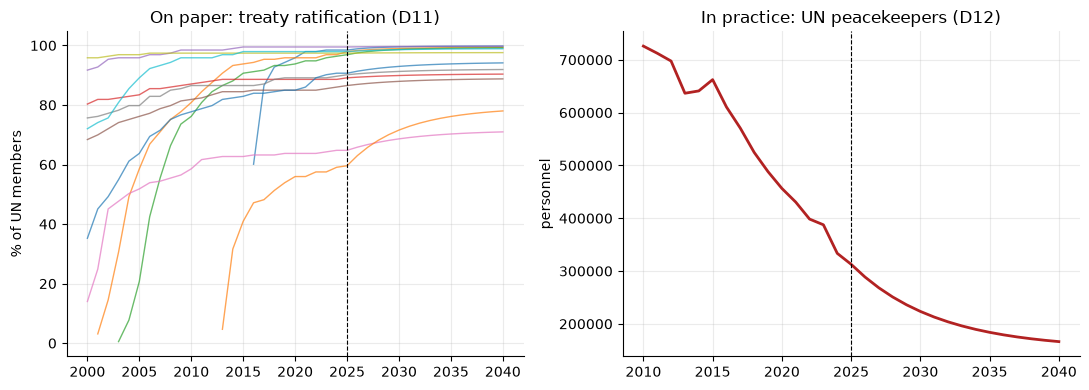

In [17]:
# Commitment on paper vs collective action in practice
paper = af.get_series(full_data_to_2040, [f"D11_{k}" for k in range(1, 13)], markets="GLO")
practice = af.get_series(full_data_to_2040, ["D12"], markets="GLO")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for pid, group in paper.groupby("id"):
    ax1.plot(group["year"], group["value"], lw=1, alpha=0.7)
ax1.axvline(2025, ls="--", c="k", lw=0.8)
ax1.set_title("On paper: treaty ratification (D11)")
ax1.set_ylabel("% of UN members")

ax2.plot(practice["year"], practice["value"], lw=2, color="firebrick")
ax2.axvline(2025, ls="--", c="k", lw=0.8)
ax2.set_title("In practice: UN peacekeepers (D12)")
ax2.set_ylabel("personnel")
plt.tight_layout()
plt.show()

# Q4: How is power exercised — rules, money, force, resources, or tech?

Levers: Military D1 | Economic D2, D4, D15 | Resource D13 | Technology D16 | Rules-based see Q3.

In [ ]:
q4_power_levers = {
    "Military":   ["D1"],
    "Economic":   ["D2", "D4", "D15"],
    "Resource":   ["D13"],
    "Technology": ["D16"],
}

q4_growth = af.power_type_growth(main_2025_data, main_2040_data, q4_power_levers).rename(
    columns={"world_total_start": "world_total_2025", "world_total_end": "world_total_2040"}
)
display(q4_growth)
print("Read as relative, not absolute — see the damping check above.")

In [ ]:
# Per-country power signature
q4_profile = af.power_profile(main_2040_data, q4_power_levers)
print("signature counts:", dict(q4_profile["signature"].value_counts()))
display(q4_profile)

for lever in q4_power_levers:
    col = f"{lever}_share"
    top = q4_profile.sort_values(col, ascending=False).head(3)
    print(f"{lever:12} -> " + ", ".join(f"{r.market} {getattr(r, col):.0f}%" for r in top.itertuples()))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
levers = list(q4_power_levers)
top10 = q4_profile.head(10)
bottom = np.zeros(len(top10))
for lever in levers:
    ax.bar(top10["market"], top10[f"{lever}_share"], bottom=bottom, label=lever)
    bottom += top10[f"{lever}_share"].to_numpy()
ax.set_title("2040 power mix of the top 10 (sum of world shares by lever)")
ax.set_ylabel("sum of world shares (%)")
ax.legend()
plt.show()

# Topic 2: Technology

## Q1: What becomes technologically possible by 2040 — and how quickly?

Frontier proxies are GLO-only: D18 training compute, D19 TOP500 #1, D20 genome cost, D57 social-media minutes.

**This question cannot be answered from our data.** D18 is a constant and D20 floors at zero, and the
damped model flattens the one working exponential (D19). We report what history shows and source the
frontier itself externally.

In [ ]:
# The frontier in history vs in our forecast — the gap is the point
frontier_hist = af.growth_profile(full_data_to_2040, ["D19"], market="GLO", years=(2010, 2025), history_start=2000)
frontier_fwd = af.growth_profile(full_data_to_2040, ["D19"], market="GLO", years=(2025, 2040), history_start=2010)

print("TOP500 #1 performance")
print(f"  2010->2025 actual:   {frontier_hist['fwd_cagr_pct'].iloc[0]:.1f}%/yr, x{frontier_hist['multiple'].iloc[0]:.0f} over 15 years")
print(f"  2025->2040 forecast: {frontier_fwd['fwd_cagr_pct'].iloc[0]:.1f}%/yr, x{frontier_fwd['multiple'].iloc[0]:.1f} over 15 years")

d19 = af.get_series(full_data_to_2040, "D19", markets="GLO")
fig, ax = plt.subplots()
ax.semilogy(d19["year"], d19["value"], lw=2)
ax.axvline(2025, ls="--", c="k", lw=0.8)
ax.set_title("TOP500 #1 performance (log scale) — 15 years of exponential, then a flat line")
ax.set_ylabel("TFlop/s")
plt.show()

## Q2: Who can build, access and control advanced technology?

Additive proxies analysed as share-of-world: D16 R&D, D22 high-tech exports, D24 medium/high-tech
manufacturing VA, D26 journal articles, D27 ICT service exports, D30 data-centre revenue, D31 semiconductors.

In [ ]:
Q2_CONTROL_IDS = ["D16", "D22", "D24", "D26", "D27", "D30", "D31"]

tech_share = af.share_trajectory(full_data_to_2040, Q2_CONTROL_IDS, YEARS)
display(tech_share.head(10))

fig, ax = plt.subplots()
for mkt in tech_share.head(6).index:
    ax.plot(YEARS, tech_share.loc[mkt], lw=2 if mkt in ("USA", "CHN") else 1, label=mkt)
ax.axvline(2025, ls="--", c="k", lw=0.8)
ax.set_title("Share of world technology production")
ax.set_ylabel("% of world")
ax.legend()
plt.show()

In [ ]:
display(af.concentration_trend(full_data_to_2040, Q2_CONTROL_IDS, YEARS))

# Who controls WHICH part of the stack?
_, tech_hhi, tech_detail = af.analyze_share_of_world(
    main_2040_data[main_2040_data["id"].isin(Q2_CONTROL_IDS)], Q2_CONTROL_IDS
)
stack = tech_detail.pivot_table(index="market", columns="id", values="share").round(1)
stack = stack.loc[stack.mean(axis=1).sort_values(ascending=False).index]
stack.columns = [f"{c}\n{PROXY_NAME[c].split('(')[0].strip()[:18]}" for c in stack.columns]
display(stack.head(8))

tech_hhi["proxy_name"] = tech_hhi["id"].map(PROXY_NAME)
display(tech_hhi.sort_values("hhi", ascending=False).round(0))

## Q3: How will technology change work, skills and the value of human contribution?

D32 robot import intensity, D33 ICT-specialist employment, D35 ICT graduates,
D36 labour productivity growth, D39 labour income share.

In [ ]:
Q3_WORK_IDS = ["D32", "D33", "D35", "D36", "D39"]

work_div = af.divergence(full_data_to_2040, Q3_WORK_IDS)
work_div["proxy_name"] = work_div["id"].map(PROXY_NAME)
display(work_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_2025", "cv_2040", "cv_change_pct", "verdict"]])

In [ ]:
# Labour's share of income — the automation question
labour = af.anchor_table(full_data_to_2040, "D39", years=[2025, 2040]).set_index("market")
print(f"world mean {labour[2025].mean():.1f}% -> {labour[2040].mean():.1f}% | "
      f"falling in {(labour['change'] < 0).sum()} of {len(labour)} countries")
display(labour.sort_values("change").head(5).round(1))

# D32 caveat: this is IMPORT intensity, so entrepot economies distort it
robots = af.anchor_table(full_data_to_2040, "D32", years=[2025, 2040]).set_index("market")
print("\ntop robot import intensity 2040:", ", ".join(f"{i}" for i in robots[2040].nlargest(5).index))
print("-> Netherlands and Canada lead on imports, not on installed density. Use IFR for real density.")

## Q4: Who captures the gains, and who bears the costs?

Access measures (D28 internet use, D48 affordability, D46/D47 gaps) vs capture measures
(D42 domestic value added, D43 net IP income, D44 digital services balance, D183a top-1% share).

In [ ]:
Q4_ACCESS_IDS = ["D28", "D48", "D46", "D47"]
Q4_CAPTURE_IDS = ["D42", "D29", "D33", "D183a"]

gains_div = af.divergence(full_data_to_2040, Q4_ACCESS_IDS + Q4_CAPTURE_IDS)
gains_div["proxy_name"] = gains_div["id"].map(PROXY_NAME)
gains_div["layer"] = np.where(gains_div["id"].isin(Q4_ACCESS_IDS), "access", "capability / capture")
display(gains_div[["layer", "id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]]
        .sort_values(["layer", "cv_change_pct"]))

In [ ]:
# Who owns the rents? Net IP income and digital services balance
for pid in ["D43", "D44"]:
    bal = af.anchor_table(full_data_to_2040, pid, years=[2025, 2040]).set_index("market")
    print(f"{pid} {PROXY_NAME[pid]}: {(bal[2040] > 0).sum()} of {len(bal)} in surplus at 2040")
    print("   largest surplus:", ", ".join(f"{i} {v:,.0f}" for i, v in bal[2040].nlargest(3).items()))
    print("   largest deficit:", ", ".join(f"{i} {v:,.0f}" for i, v in bal[2040].nsmallest(3).items()))

ip = af.anchor_table(full_data_to_2040, "D43", years=[2025, 2040]).set_index("market")[2040].sort_values()
fig, ax = plt.subplots()
colors = ["firebrick" if v < 0 else "seagreen" for v in ip]
ax.barh(ip.index, ip.to_numpy(), color=colors)
ax.set_title("2040 net intellectual-property income (USD m) — who pays rent, who collects it")
plt.tight_layout()
plt.show()

## Q5: Does technology strengthen human agency, trust and social connection — or weaken them?

D49-D56, all V-Dem / Freedom House / UN scores already oriented so **higher = more freedom or capability**.
No inversion needed — confirmed against the proxy descriptions.

In [ ]:
Q5_STATE_IDS = ["D49", "D50", "D51", "D53", "D54", "D55"]   # constraint on the citizen
Q5_CITIZEN_IDS = ["D52", "D56"]                              # capability of the citizen

for pid in Q5_STATE_IDS + Q5_CITIZEN_IDS:
    a = af.anchor_table(full_data_to_2040, pid, years=[2025, 2040]).set_index("market")
    better = int((a["change"] > 0.05).sum())
    worse = int((a["change"] < -0.05).sum())
    side = "state control" if pid in Q5_STATE_IDS else "citizen capability"
    print(f"{pid} [{side:18}] mean {a[2025].mean():6.2f} -> {a[2040].mean():6.2f} "
          f"| improving {better:2d}  worsening {worse:2d}  flat {len(a) - better - worse:2d}")

In [ ]:
agency_div = af.divergence(full_data_to_2040, Q5_STATE_IDS + Q5_CITIZEN_IDS)
agency_div["side"] = np.where(agency_div["id"].isin(Q5_STATE_IDS), "state control", "citizen capability")
display(agency_div[["side", "id", "cv_2025", "cv_2040", "cv_change_pct", "verdict"]].sort_values("side"))

In [ ]:
# Three digital-society regimes
regime_assign, regime_profile = af.typology(main_2040_data, Q5_STATE_IDS + Q5_CITIZEN_IDS, k=3)
display(regime_profile.drop(columns="members"))
for cluster, row in regime_profile.iterrows():
    print(f"cluster {cluster} (n={row['n']}): {row['members']}")

In [ ]:
q5_config = [{"id": pid, "direction": "positive"} for pid in Q5_STATE_IDS + Q5_CITIZEN_IDS]
for label, data in [("2025", main_2025_data), ("2040", main_2040_data)]:
    ranking = af.rank_market_relevance(data[data["id"].isin(Q5_STATE_IDS + Q5_CITIZEN_IDS)], q5_config)
    print(f"{label} freest: {', '.join(ranking.head(5)['market'])}  |  "
          f"least free: {', '.join(ranking.tail(5)['market'])}")

# Topic 3: Planet

## Q1: How fast are planetary pressures intensifying?

D58-D61a are GLO context series; D62-D64 are national contribution.

**The physical levels here are not usable as forecasts** — the damped model flattens every
accelerating series. Levels come from IPCC / Climate Action Tracker in the write-up.
What our data *can* say is who contributes, and how that distribution is changing.

In [ ]:
# Why the physical series cannot be quoted
planet_state = af.growth_profile(full_data_to_2040, ["D58", "D59", "D60", "D61", "D61a"],
                                 market="GLO", history_start=2010)
planet_state["proxy_name"] = planet_state["proxy_id"].map(PROXY_NAME)
display(planet_state)
print("CO2 forecast implies ~0.5 ppm/yr against an observed ~2.5 ppm/yr; sea level ~0.8 mm/yr against ~4 mm/yr.")

In [ ]:
# Emissions responsibility is CONCENTRATING — the opposite of power
emit_share = af.share_trajectory(full_data_to_2040, ["D62"], [2000, 2010, 2025, 2040])
display(emit_share.head(8))
display(af.concentration_trend(full_data_to_2040, ["D62"], [2000, 2010, 2025, 2040]))

# Per-capita emissions: is anyone converging?
display(af.divergence(full_data_to_2040, ["D62", "D63", "D64"])
        [["id", "mean_2025", "mean_2040", "p90_p10_2025", "p90_p10_2040", "cv_change_pct", "verdict"]])

## Q2: Where will climate and pollution make places harder to live?

D65 temperature anomaly, D66 days above 35C, D67 extreme rainfall, D68 drought, D70 PM2.5.

In [ ]:
Q2_HAZARD_IDS = ["D65", "D66", "D67", "D68", "D70"]
hazard_div = af.divergence(full_data_to_2040, Q2_HAZARD_IDS)
hazard_div["proxy_name"] = hazard_div["id"].map(PROXY_NAME)
display(hazard_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

heat = af.anchor_table(full_data_to_2040, "D66", years=[2025, 2040]).set_index("market")
print(f"\nDays above 35C: world mean {heat[2025].mean():.1f} -> {heat[2040].mean():.1f}, "
      f"rising in {(heat['change'] > 0).sum()} of {len(heat)}")
print("worst 2040:", ", ".join(f"{i} {v:.0f}d" for i, v in heat[2040].nlargest(6).items()))

In [ ]:
# Threshold tests. Note how little these move: the damping freezes hazard counts.
heat_specs = {
    "30+ days above 35C": ("D66", 30, "above"),
    "60+ days above 35C": ("D66", 60, "above"),
    "90+ days above 35C": ("D66", 90, "above"),
    "PM2.5 above WHO 5 ug/m3": ("D70", 5, "above"),
    "PM2.5 above 35 ug/m3": ("D70", 35, "above"),
}
display(af.threshold_matrix(full_data_to_2040, heat_specs))
print("Counts barely move -> use CCKP/Copernicus scenarios for hazard trajectories, not this model.")

## Q3: Can food, water and ecosystems remain productive?

D73-D79 water and food, D82 biodiversity.

In [ ]:
Q3_SYSTEM_IDS = ["D73", "D74", "D75", "D76", "D77", "D78", "D82"]
system_div = af.divergence(full_data_to_2040, Q3_SYSTEM_IDS)
system_div["proxy_name"] = system_div["id"].map(PROXY_NAME)
display(system_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

stress_specs = {
    "water stress above 25%": ("D73", 25, "above"),
    "freshwater below 1700 m3/cap": ("D74", 1700, "below"),
    "food insecurity above 20%": ("D78", 20, "above"),
}
display(af.threshold_matrix(full_data_to_2040, stress_specs))

## Q4: Can energy and material systems decarbonise without new dependencies?

D83-D91. The question is whether the whole energy system moves, or only one sector of it.

In [ ]:
Q4_TRANSITION_IDS = ["D83", "D84", "D85", "D86", "D87", "D88", "D90", "D91"]
trans_div = af.divergence(full_data_to_2040, Q4_TRANSITION_IDS)
trans_div["proxy_name"] = trans_div["id"].map(PROXY_NAME)
display(trans_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

for pid in ["D83", "D85", "D87", "D88"]:
    a = af.anchor_table(full_data_to_2040, pid, years=[2025, 2040]).set_index("market")
    print(f"{pid} {PROXY_NAME[pid][:42]:44} {a[2025].mean():8.2f} -> {a[2040].mean():8.2f}"
          f"   (rising in {int((a['change'] > 0).sum())}/{len(a)})")

In [ ]:
# One sector moves, the rest does not
fig, ax = plt.subplots()
for pid, colour in [("D88", "seagreen"), ("D83", "steelblue"), ("D85", "firebrick"), ("D87", "grey")]:
    s = af.get_series(full_data_to_2040, pid, years=YEARS)
    m = s.groupby("year")["value"].mean()
    ax.plot(m.index, m / m.loc[2025] * 100, lw=2, color=colour, label=f"{pid} {PROXY_NAME[pid].split('(')[0][:26]}")
ax.axhline(100, c="k", lw=0.6)
ax.axvline(2025, ls="--", c="k", lw=0.8)
ax.set_title("Transition indicators, indexed to 2025 = 100 (34-country mean)")
ax.legend(fontsize=8)
plt.show()

## Q5: Who can adapt, absorb losses and recover — and who is left exposed?

D92 vulnerability, D93 readiness, D94 lack of coping capacity — crossed against the Q2 hazard set.
This is the distributional core of the topic: does exposure line up with incapacity?

In [ ]:
adapt_div = af.divergence(full_data_to_2040, ["D92", "D93", "D94"])
adapt_div["proxy_name"] = adapt_div["id"].map(PROXY_NAME)
display(adapt_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_2025", "cv_2040", "cv_change_pct", "verdict"]])

for pid, better in [("D92", "lower"), ("D93", "higher"), ("D94", "lower")]:
    a = af.anchor_table(full_data_to_2040, pid, years=[2025, 2040]).set_index("market")
    improving = (a["change"] < 0).sum() if better == "lower" else (a["change"] > 0).sum()
    print(f"{pid}: improving in {improving}/{len(a)} countries, dispersion essentially unchanged")

In [ ]:
# The adaptation divide: exposure vs capacity
EXPOSURE_CONFIG = [
    {"id": "D66", "direction": "positive"},   # heat days
    {"id": "D68", "direction": "positive"},   # drought
    {"id": "D70", "direction": "positive"},   # PM2.5
    {"id": "D73", "direction": "positive"},   # water stress
    {"id": "D74", "direction": "negative"},   # freshwater per capita
]
CAPACITY_CONFIG = [
    {"id": "D93", "direction": "positive"},   # readiness
    {"id": "D92", "direction": "negative"},   # vulnerability
    {"id": "D94", "direction": "negative"},   # lack of coping capacity
]
QUAD_NAMES = {
    (True, False): "Exposed & unable",
    (True, True): "Exposed but capable",
    (False, True): "Sheltered & capable",
    (False, False): "Sheltered but unable",
}

for label, data in [("2025", main_2025_data), ("2040", main_2040_data)]:
    q = af.quadrant_map(data, EXPOSURE_CONFIG, CAPACITY_CONFIG, "exposure", "capacity",
                        quadrant_names=QUAD_NAMES)
    print(f"{label}: corr(exposure, capacity) = {af.alignment_score(q, 'exposure', 'capacity'):+.3f}"
          f" | {dict(q['quadrant'].value_counts())}")

quad_2040 = af.quadrant_map(main_2040_data, EXPOSURE_CONFIG, CAPACITY_CONFIG,
                            "exposure", "capacity", quadrant_names=QUAD_NAMES)
display(quad_2040.head(12))

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
palette = {"Exposed & unable": "firebrick", "Exposed but capable": "darkorange",
           "Sheltered & capable": "seagreen", "Sheltered but unable": "steelblue"}
for name, group in quad_2040.groupby("quadrant"):
    ax.scatter(group["exposure"], group["capacity"], s=55, label=name, color=palette[name])
for r in quad_2040.itertuples():
    ax.annotate(r.market, (r.exposure, r.capacity), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.axhline(50, c="k", lw=0.6)
ax.axvline(50, c="k", lw=0.6)
ax.set_xlabel("physical exposure (higher = more exposed)")
ax.set_ylabel("adaptive capacity (higher = more able)")
ax.set_title("The adaptation divide, 2040")
ax.legend(fontsize=8, loc="lower left")
plt.show()

# Topic 4: People

## Q1: How will population size and age structure change?

D100-D107. Levels are damped and should be anchored to UN WPP; the *spread* between countries
is the reliable signal here, and it is the widest of any topic.

In [ ]:
Q1_DEMO_IDS = ["D100", "D101", "D102", "D103", "D104", "D105", "D106", "D107"]
demo_div = af.divergence(full_data_to_2040, Q1_DEMO_IDS)
demo_div["proxy_name"] = demo_div["id"].map(PROXY_NAME)
display(demo_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

In [ ]:
demo_specs = {
    "65+ share at/above 20%": ("D104", 20, "above"),
    "65+ share at/above 25%": ("D104", 25, "above"),
    "median age at/above 45": ("D103", 45, "above"),
    "fertility below 2.1 (replacement)": ("D101", 2.1, "below"),
    "fertility below 1.5 (ultra-low)": ("D101", 1.5, "below"),
    "working-age population shrinking": ("D107", 0, "below"),
}
display(af.threshold_matrix(full_data_to_2040, demo_specs))

In [ ]:
# The two demographic worlds
age = af.anchor_table(full_data_to_2040, "D103", years=[2025, 2040]).set_index("market")[2040].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(age.index, age.to_numpy(),
        color=["firebrick" if v >= 45 else "steelblue" if v <= 25 else "lightgrey" for v in age])
ax.axvline(45, ls="--", c="firebrick", lw=1)
ax.axvline(25, ls="--", c="steelblue", lw=1)
ax.set_title("Median age in 2040 — a 33-year spread between the oldest and youngest society")
plt.tight_layout()
plt.show()

## Q2: Where will people live — and who will move?

D108-D115.

In [ ]:
Q2_MOVE_IDS = ["D108", "D109", "D110", "D111", "D112", "D113", "D115"]
move_div = af.divergence(full_data_to_2040, Q2_MOVE_IDS)
move_div["proxy_name"] = move_div["id"].map(PROXY_NAME)
display(move_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

mig = af.anchor_table(full_data_to_2040, "D112", years=[2025, 2040]).set_index("market")
print(f"net migration 2040: {int((mig[2040] > 0).sum())} receivers, {int((mig[2040] < 0).sum())} senders")
print("  receivers:", ", ".join(f"{i} {v:+.1f}" for i, v in mig[2040].nlargest(4).items()))
print("  senders:  ", ", ".join(f"{i} {v:+.1f}" for i, v in mig[2040].nsmallest(4).items()))

## Q3: Can societies sustain health, education and care across longer lives?

D116-D124a. The headline pattern: means improve and dispersion falls — except where it doesn't.

In [ ]:
Q3_CARE_IDS = ["D116", "D117", "D118", "D119", "D120", "D121", "D123", "D124", "D124a"]
care_div = af.divergence(full_data_to_2040, Q3_CARE_IDS)
care_div["proxy_name"] = care_div["id"].map(PROXY_NAME)
display(care_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_2025", "cv_2040", "cv_change_pct", "verdict"]])

# Maternal mortality is the exception: mean falls, spread widens
mmr = af.gap_movers(full_data_to_2040, "D117")
print("D117 maternal mortality — pulling away from the world mean (worse):")
display(mmr.head(4))

## Q4: Who gains security, opportunity and a livable standard?

D125-D183a. Absolute progress with relative divergence is the recurring shape.

In [ ]:
Q4_INCLUSION_IDS = ["D125", "D126", "D127", "D128", "D129", "D131", "D133", "D183a"]
incl_div = af.divergence(full_data_to_2040, Q4_INCLUSION_IDS)
incl_div["proxy_name"] = incl_div["id"].map(PROXY_NAME)
display(incl_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

## Q5: Where will accumulated pressure turn into mistrust, protest or instability?D134-D141.**Data-direction bug, fixed at source 2026-08-17:** D141's Proxy Information description saidhigher = more polarised, but the raw V-Dem field (v2smpolsoc) is reverse-coded — 0 = seriouspolarisation, 4 = no polarisation. So higher = LESS polarised (more consensus). The stored *values*were always correct; only the description was backwards. This has now been corrected inFinal Data.xlsx (Proxy Information sheet) and the Topic 3-5 Proxy Registry. The cell below is asanity check confirming the fix reads correctly against known cases (US and Poland becoming morepolarised, China staying low on this measure) before using D141 with `direction="negative"` below.

In [ ]:
# Direction check on D141 before using it
pol_check = af.get_series(full_data_to_2040, "D141", markets=["USA", "POL", "BRA", "CHN", "NLD"],
                          years=[2000, 2015, 2020, 2025, 2040])
display(pol_check.pivot_table(index="market", columns="year", values="value").round(2))
print("USA/POL/BRA fall sharply (they became more polarised) while CHN stays high -> the scale is inverted.")

In [ ]:
Q5_COHESION_IDS = ["D134", "D135", "D136", "D137", "D138", "D139", "D141"]
coh_div = af.divergence(full_data_to_2040, Q5_COHESION_IDS)
coh_div["proxy_name"] = coh_div["id"].map(PROXY_NAME)
display(coh_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

# civic space vs mobilisation, using corrected D141 direction
for pid, more_is in [("D134", "better"), ("D135", "better"), ("D136", "better"),
                     ("D137", "more protest"), ("D138", "more violence"), ("D141", "less polarised")]:
    a = af.anchor_table(full_data_to_2040, pid, years=[2025, 2040]).set_index("market")
    print(f"{pid} [{more_is:14}] mean {a[2025].mean():+8.2f} -> {a[2040].mean():+8.2f} "
          f"| up in {int((a['change'] > 0.005).sum()):2d}  down in {int((a['change'] < -0.005).sum()):2d}")

In [ ]:
# Pressure vs the institutions meant to absorb it
PRESSURE_CONFIG = [
    {"id": "D128", "direction": "positive"},   # youth unemployment
    {"id": "D123", "direction": "positive"},   # NEET
    {"id": "D125", "direction": "positive"},   # poverty
    {"id": "D131", "direction": "positive"},   # informality
    {"id": "D110", "direction": "positive"},   # slum residence
    {"id": "D105", "direction": "positive"},   # youth share
]
INSTITUTION_CONFIG = [
    {"id": "D134", "direction": "positive"},   # voice and accountability
    {"id": "D135", "direction": "positive"},   # civil society
    {"id": "D136", "direction": "positive"},   # assembly
    {"id": "D119", "direction": "positive"},   # UHC coverage
]
PEOPLE_QUADS = {
    (True, False): "Pressured & brittle",
    (True, True): "Pressured but absorbing",
    (False, True): "Calm & capable",
    (False, False): "Calm but brittle",
}

for label, data in [("2025", main_2025_data), ("2040", main_2040_data)]:
    q = af.quadrant_map(data, PRESSURE_CONFIG, INSTITUTION_CONFIG, "pressure", "institutions",
                        quadrant_names=PEOPLE_QUADS)
    print(f"{label}: corr = {af.alignment_score(q, 'pressure', 'institutions'):+.3f} "
          f"| {dict(q['quadrant'].value_counts())}")

people_quad = af.quadrant_map(main_2040_data, PRESSURE_CONFIG, INSTITUTION_CONFIG,
                              "pressure", "institutions", quadrant_names=PEOPLE_QUADS)
display(people_quad.head(12))

# Topic 5: Economy

## Q1: Where will economic scale, income and productivity shift?

D142-D149. Shares are the reliable output here; levels are damped.

In [ ]:
for pid in ["D143", "D151", "D152", "D159"]:
    a = af.anchor_table(full_data_to_2040, pid, years=[2000, 2025, 2040]).set_index("market")
    top = a[2040].nlargest(5).index
    print(f"{pid} {PROXY_NAME[pid][:44]:46}")
    print("   " + " | ".join(f"{i} {a.loc[i, 2000]:.1f}->{a.loc[i, 2025]:.1f}->{a.loc[i, 2040]:.1f}" for i in top))

scale_div = af.divergence(full_data_to_2040, ["D142", "D144", "D145", "D146", "D147", "D148", "D149"])
scale_div["proxy_name"] = scale_div["id"].map(PROXY_NAME)
display(scale_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

## Q2: Is trade integrating, fragmenting or rewiring into blocs?D150-D157, plus D158 (built 2026-08-17, see below). D150-D157 are gross aggregates — they see the*level* of integration but not bloc rewiring underneath it. D158 fills that gap directly.

In [ ]:
Q2_TRADE_IDS = ["D150", "D153", "D154", "D155", "D156", "D157"]
trade_div = af.divergence(full_data_to_2040, Q2_TRADE_IDS)
trade_div["proxy_name"] = trade_div["id"].map(PROXY_NAME)
display(trade_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

for pid in ["D150", "D153", "D155", "D157"]:
    a = af.anchor_table(full_data_to_2040, pid, years=[2025, 2040]).set_index("market")
    print(f"{pid} {PROXY_NAME[pid][:40]:42} {a[2025].mean():7.2f} -> {a[2040].mean():7.2f} "
          f"(rising in {int((a['change'] > 0).sum())}/{len(a)})")
print("\nOpenness up, tariffs down, intra-regional share DOWN -> no regionalisation in the aggregates.")

### D158 — Trade concentration by geopolitical blocBuilt by reusing the cached UN Comtrade bilateral extract from D153(`Raw Data/Topic 3-5/UN Comtrade/Original/Derived Proxies/D153_intraregional_total.json`, 318kreporter-partner-year records, 2000-2024): each country's two-way trade (M+X) is split into West bloc /China+Russia bloc / Rest of world, then HHI'd, same convention as D163. Forecast through the pipeline'sisolated per-proxy path — the other 189 proxies were not touched. See `MODEL_LIMITATIONS.md` andTopic 5 Appendix B for method and coverage caveats.

In [ ]:
D158_direction = af.anchor_table(full_data_to_2040, "D158", years=[2025, 2030, 2040]).set_index("market")print(f"world mean bloc-HHI: {D158_direction[2025].mean():.0f} -> {D158_direction[2030].mean():.0f} "      f"-> {D158_direction[2040].mean():.0f}")print(f"falling (diversifying) in {int((D158_direction['change'] < 0).sum())} of {len(D158_direction)}; "      f"rising (consolidating) in {int((D158_direction['change'] > 0).sum())}")display(af.divergence(full_data_to_2040, ["D158"])[["id", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])# scenario robustness + cross-check against D153 (intra-regional trade)spread = af.scenario_spread(full_data_to_2040, ["D158"], 2040)print(f"\nscenario-robust in {int(spread['scenario_robust'].sum())}/{len(spread)} countries "      f"(median spread {spread['spread_pct'].median():.1f}%)")a153 = af.anchor_table(full_data_to_2040, "D153", years=[2040]).set_index("market")[2040]a158 = D158_direction[2040]print(f"corr(D153 intra-regional trade %, D158 bloc HHI) = {a153.corr(a158):.2f}")

In [ ]:
# West / China+Russia / Rest -- does concentration differ by which bloc you're in?WEST_BLOC = {"USA", "CAN", "GBR", "FRA", "DEU", "ITA", "NLD", "POL", "JPN", "KOR", "AUS"}CHINA_RUSSIA_BLOC = {"CHN", "RUS"}grouped = D158_direction.reset_index()grouped["group"] = grouped["market"].map(    lambda m: "West" if m in WEST_BLOC else ("China+Russia" if m in CHINA_RUSSIA_BLOC else "Rest/Non-aligned"))display(grouped.groupby("group")[[2025, 2040]].mean().round(0))print("\nmost concentrated 2040:", ", ".join(f"{i} {v:.0f}" for i, v in D158_direction[2040].nlargest(5).items()))print("most diversified 2040: ", ", ".join(f"{i} {v:.0f}" for i, v in D158_direction[2040].nsmallest(5).items()))

## Q3: Who controls production, supply chains and strategic inputs?

D159-D167.

In [ ]:
Q3_PROD_IDS = ["D159", "D160", "D161", "D162", "D163", "D164", "D165", "D166", "D167"]
prod_div = af.divergence(full_data_to_2040, Q3_PROD_IDS)
prod_div["proxy_name"] = prod_div["id"].map(PROXY_NAME)
display(prod_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

mfg = af.anchor_table(full_data_to_2040, "D159", years=[2025, 2040]).set_index("market")
print("world manufacturing VA share 2040:",
      ", ".join(f"{i} {v:.1f}%" for i, v in mfg[2040].nlargest(5).items()))

## Q4: How much financial and fiscal instability can economies absorb?

D168-D175. This is the most uniformly diverging question set in the whole framework.

In [ ]:
Q4_FIN_IDS = ["D168", "D169", "D170", "D171", "D172", "D173", "D174", "D175"]
fin_div = af.divergence(full_data_to_2040, Q4_FIN_IDS)
fin_div["proxy_name"] = fin_div["id"].map(PROXY_NAME)
display(fin_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

fin_specs = {
    "debt above 100% of GDP": ("D169", 100, "above"),
    "debt above 60% of GDP": ("D169", 60, "above"),
    "interest above 10% of revenue": ("D170", 10, "above"),
    "reserves below 3 months": ("D171", 3, "below"),
    "NPLs above 5%": ("D175", 5, "above"),
    "inflation above 5%": ("D168", 5, "above"),
}
display(af.threshold_matrix(full_data_to_2040, fin_specs))

In [ ]:
# The asymmetry: rich countries carry the debt, poor countries carry the debt SERVICE
debt = af.anchor_table(full_data_to_2040, "D169", years=[2025, 2040]).set_index("market")[2040]
interest = af.anchor_table(full_data_to_2040, "D170", years=[2025, 2040]).set_index("market")[2040]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
both = pd.DataFrame({"debt": debt, "interest": interest}).dropna()
ax.scatter(both["debt"], both["interest"], s=45)
for r in both.itertuples():
    ax.annotate(r.Index, (r.debt, r.interest), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("government gross debt (% of GDP), 2040")
ax.set_ylabel("interest payments (% of government revenue), 2040")
ax.set_title("Debt level and debt burden are almost unrelated")
plt.show()
print("corr:", round(both["debt"].corr(both["interest"]), 3))

## Q5: Does growth create broad prosperity — or insecurity?

D176-D182.

In [ ]:
Q5_PROSP_IDS = ["D176", "D177", "D178", "D180", "D181", "D182"]
prosp_div = af.divergence(full_data_to_2040, Q5_PROSP_IDS)
prosp_div["proxy_name"] = prosp_div["id"].map(PROXY_NAME)
display(prosp_div[["id", "proxy_name", "mean_2025", "mean_2040", "cv_change_pct", "verdict"]])

In [ ]:
# Financial stress vs the buffers to absorb it
STRESS_CONFIG = [{"id": pid, "direction": "positive"} for pid in ["D169", "D170", "D173", "D168", "D175"]]
BUFFER_CONFIG = [{"id": pid, "direction": "positive"} for pid in ["D171", "D181", "D172", "D144"]]
ECON_QUADS = {
    (True, False): "Stressed & unbuffered",
    (True, True): "Stressed but buffered",
    (False, True): "Calm & buffered",
    (False, False): "Calm but unbuffered",
}

for label, data in [("2025", main_2025_data), ("2040", main_2040_data)]:
    q = af.quadrant_map(data, STRESS_CONFIG, BUFFER_CONFIG, "stress", "buffers", quadrant_names=ECON_QUADS)
    print(f"{label}: corr = {af.alignment_score(q, 'stress', 'buffers'):+.3f} "
          f"| {dict(q['quadrant'].value_counts())}")

econ_quad = af.quadrant_map(main_2040_data, STRESS_CONFIG, BUFFER_CONFIG,
                            "stress", "buffers", quadrant_names=ECON_QUADS)
display(econ_quad.head(10))

# Cross-topic: the compound-risk overlap

The same quadrant logic applied to Planet, People and Economy uses three completely independent
proxy sets. If the worst quadrant of each contains the same countries, that is not an artefact of
one indicator — it is structure.

In [ ]:
worst_quadrants = {
    "Planet: exposed & unable": (EXPOSURE_CONFIG, CAPACITY_CONFIG),
    "People: pressured & brittle": (PRESSURE_CONFIG, INSTITUTION_CONFIG),
    "Economy: stressed & unbuffered": (STRESS_CONFIG, BUFFER_CONFIG),
}

worst_members = {}
for name, (x_cfg, y_cfg) in worst_quadrants.items():
    q = af.quadrant_map(main_2040_data, x_cfg, y_cfg, "x", "y")
    members = set(q.loc[(q["x"] >= 50) & (q["y"] < 50), "market"])
    worst_members[name] = members
    print(f"{name} (n={len(members)}): {', '.join(sorted(members))}")

triple = set.intersection(*worst_members.values())
print(f"\nIn the worst quadrant of ALL THREE topics ({len(triple)}): {', '.join(sorted(triple))}")

counts = pd.Series([m for members in worst_members.values() for m in members]).value_counts()
display(counts[counts >= 2].rename("topics_in_worst_quadrant").to_frame())